# **Intra- and Inter-Similarity Densities**

Author: Aditya Khadkikar

Credit: https://github.com/serengil/deepface/blob/master/experiments/distance-to-confidence.ipynb

Original code from above adapted and moderately refactored for working with this project.

> Because of the files being excessively large in size, outputs are not stored. Run the notebooks to achieve the outputs. You need the necessary libraries in this notebook, and a ZIP folder of all of the images named as intra-sim.zip.

In [ ]:
! pip install deepface

# built-in dependencies
import itertools
import math, os

# 3rd party dependencies
import pandas as pd
pd.set_option('display.max_rows', None)
from deepface import DeepFace
from deepface.modules.verification import find_distance, find_threshold
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [2]:
detectors = ["mtcnn", "dlib", "retinaface"]
model_names = ["Facenet512", "VGG-Face", "ArcFace"]
distance_metrics = ["cosine", "euclidean"]

## **Preparing the images**

To be put in the form as shown below:

```py
identities = {
 "Angelina": ["img1.jpg", "img2.jpg", "img4.jpg"
    , "img5.jpg", "img6.jpg", "img7.jpg", "img10.jpg", "img11.jpg"],
 "Scarlett": ["img8.jpg", "img9.jpg"],
 "Jennifer": ["img3.jpg", "img12.jpg"],
 "Mark": ["img13.jpg", "img14.jpg", "img15.jpg"],
 "Jack": ["img16.jpg", "img17.jpg"],
 "Elon": ["img18.jpg", "img19.jpg"],
 "Jeff": ["img20.jpg", "img21.jpg"],
 "Marissa": ["img22.jpg", "img23.jpg"],
 "Sundar": ["img24.jpg", "img25.jpg"]
}
```

In [ ]:
! unzip intra-sim.zip

In [4]:
path = "intra-sim/"
identities = {}

for entry in os.listdir(path):
    person_collection = os.path.join(path, entry)

    if os.path.isdir(person_collection):
        identities[entry] = []
        for file_ in os.listdir(person_collection):
          identities[entry].append(str(entry+"/"+file_))

# Split into 3 subsets as the density peaks are improperly high
# 62 distinct individuals 'inter-similarity' vs 20 in the 'intra-similarity'
# hence split to 3 parts.
i_subsets = {}
i_subsets['1'] = {}
i_subsets['2'] = {}
i_subsets['3'] = {}

for k in list(identities.keys())[:20]:
    i_subsets['1'][k] = identities[k]

for k in list(identities.keys())[20:40]:
    i_subsets['2'][k] = identities[k]

for k in list(identities.keys())[40:]:
    i_subsets['3'][k] = identities[k]

## **Density Estimation** and computing Bhattacharyya Coef

> `BD_mc()` is the function that gives the estimated coefficient value using Monte-Carlo based approximation from the intra- and inter-similarity estimated distribution. To get an idea of the 95% confidence margin of the estimated coefficient, I use a technique called bootstrapping to get upper and lower bounds on the estimate (`bootstrap_CI()`).

Below are example runs of the code to get the Similarity Densities and the coefficients for different embedding types and detector backends. It saves the plots in png images as well for later analysis, so to save on the upload space, only some plots and calculated coefficient values are shown.

In [8]:
# estimating the Bhattacharyya coef with Monte-Carlo based approach
def BD_mc(p, q, n=100):
  points = p.resample(n)
  p_pdf = p.pdf(points)
  q_pdf = q.pdf(points)
  # returns the total values sampled so far, and the expected Bhattacharyya coef value
  return np.sqrt(p_pdf * q_pdf)/p_pdf, (np.sqrt(p_pdf * q_pdf)/p_pdf).mean()

In [9]:
def bootstrap_CI(bd_s, B=1000):
    """B: number of bootstrapping trials"""
    bootstrapped_bd = np.zeros(B)
    boot_length = len(bd_s)
    # For each bootstrap trial
    # Randomly pick a value from the arr of Bhattacharyya values with repl.
    for b in range(B):
        Ci_star = np.random.choice(bd_s, size = boot_length, replace = True)
        bootstrapped_bd[b] = np.mean(Ci_star)

    # Compute percentile confidence intervals
    percentile = np.quantile(bootstrapped_bd, [0.025, 0.975])
    return percentile

In [10]:
def represent(img_name: str):
  if pivot.get(img_name) is None:
      embedding_objs = DeepFace.represent(img_path=img_name, model_name=model_name, detector_backend=detector_backend)

      if len(embedding_objs) > 1:
          print(f"{img_name} has more than one face!")
          embedding_objs = [embedding_objs[max(range(len(embedding_objs)), key=lambda index: embedding_objs[index]['face_confidence'])]]

      pivot[img_name] = [embedding_obj["embedding"] for embedding_obj in embedding_objs]
  return pivot[img_name]


-------
Running an experiment for Facenet512 & mtcnn...
-------



  0%|          | 4/79800 [00:01<8:51:06,  2.50it/s] 

intra-sim/Nestor_Kirchner_/18.png has more than one face!


  0%|          | 5/79800 [00:02<7:48:57,  2.84it/s]

intra-sim/Nestor_Kirchner_/3.png has more than one face!


...

  4%|▍         | 3430/79800 [02:29<48:57, 26.00it/s]

intra-sim/Vicente_Fox_/14.png has more than one face!


  4%|▍         | 3436/79800 [02:32<1:13:11, 17.39it/s]

intra-sim/Vicente_Fox_/1.png has more than one face!


100%|██████████| 79800/79800 [00:13<00:00, 5922.68it/s]


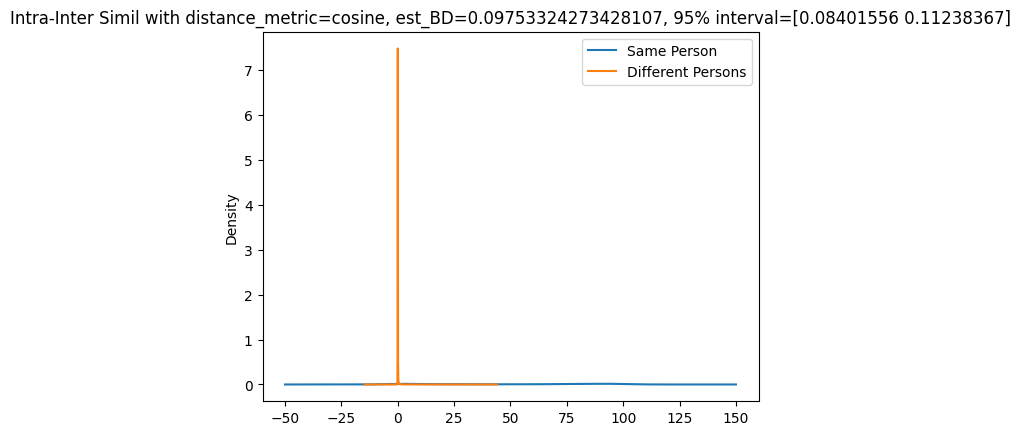

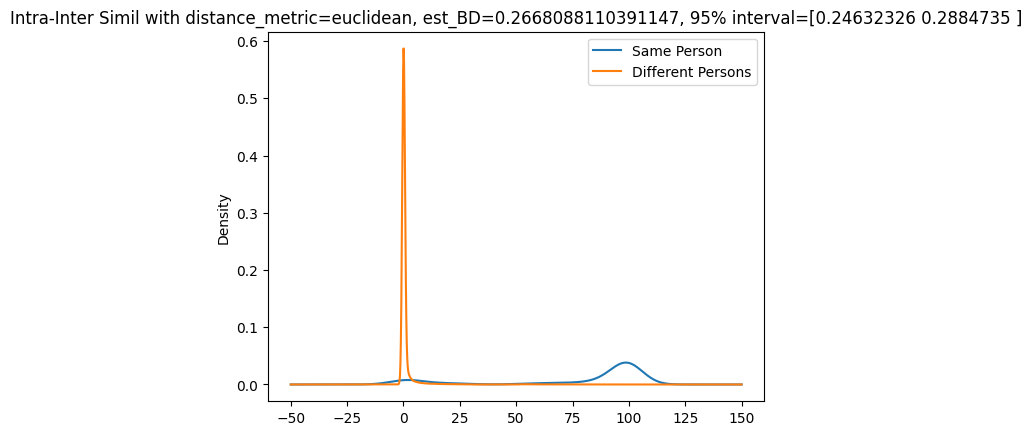


-------
Running an experiment for Facenet512 & dlib...
-------



  0%|          | 4/79800 [00:01<7:21:14,  3.01it/s]

intra-sim/Nestor_Kirchner_/18.png has more than one face!


  0%|          | 16/79800 [00:05<6:43:32,  3.30it/s]

intra-sim/Nestor_Kirchner_/1.png has more than one face!


...

  4%|▍         | 3421/79800 [02:09<31:36, 40.28it/s]  

intra-sim/Vicente_Fox_/12.png has more than one face!
intra-sim/Vicente_Fox_/3.png has more than one face!
intra-sim/Vicente_Fox_/10.png has more than one face!


  4%|▍         | 3431/79800 [02:12<49:01, 25.96it/s]

intra-sim/Vicente_Fox_/14.png has more than one face!
intra-sim/Vicente_Fox_/1.png has more than one face!


100%|██████████| 79800/79800 [00:13<00:00, 6027.65it/s]


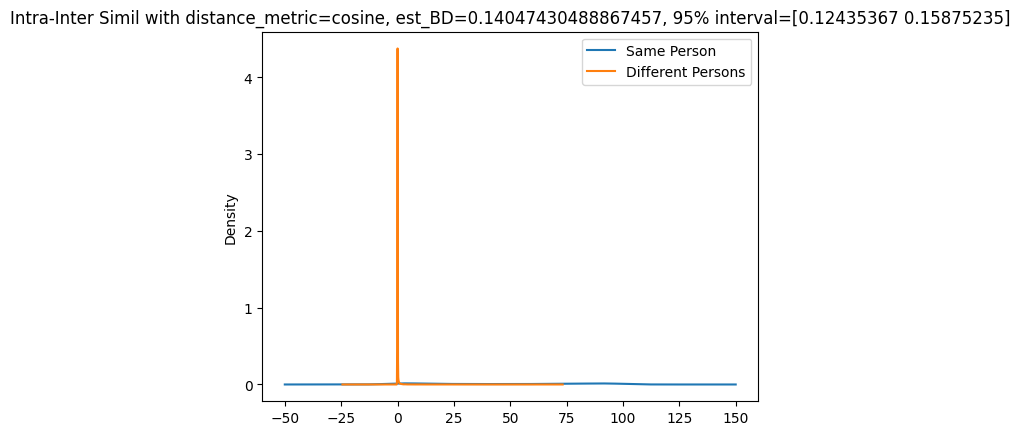

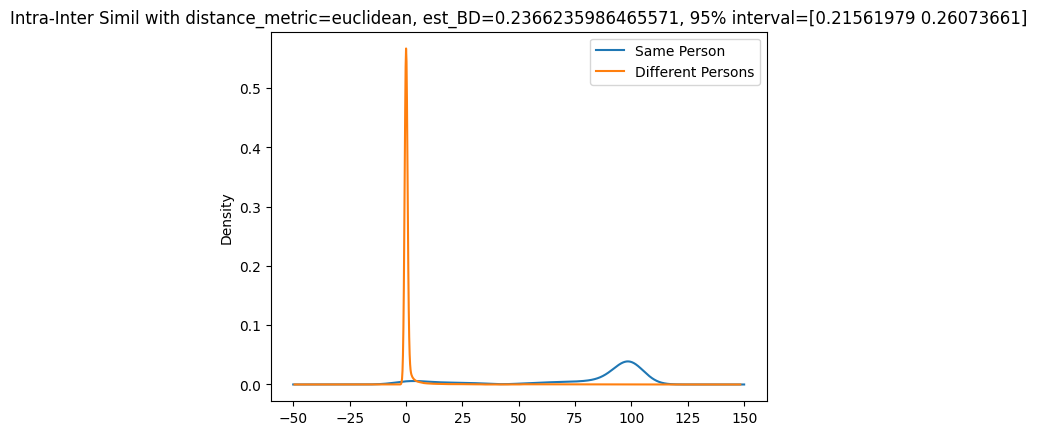


-------
Running an experiment for Facenet512 & retinaface...
-------



  0%|          | 5/79800 [00:01<5:33:28,  3.99it/s]

intra-sim/Nestor_Kirchner_/18.png has more than one face!
intra-sim/Nestor_Kirchner_/3.png has more than one face!


  0%|          | 16/79800 [00:04<5:13:15,  4.24it/s]

intra-sim/Nestor_Kirchner_/14.png has more than one face!
intra-sim/Nestor_Kirchner_/1.png has more than one face!


...

  4%|▍         | 3433/79800 [01:46<41:24, 30.73it/s]

intra-sim/Vicente_Fox_/13.png has more than one face!
intra-sim/Vicente_Fox_/14.png has more than one face!
intra-sim/Vicente_Fox_/1.png has more than one face!


  5%|▍         | 3611/79800 [01:48<22:22, 56.77it/s]

intra-sim/Junichiro_Koizumi_/6.png has more than one face!


100%|██████████| 79800/79800 [00:13<00:00, 5960.42it/s]


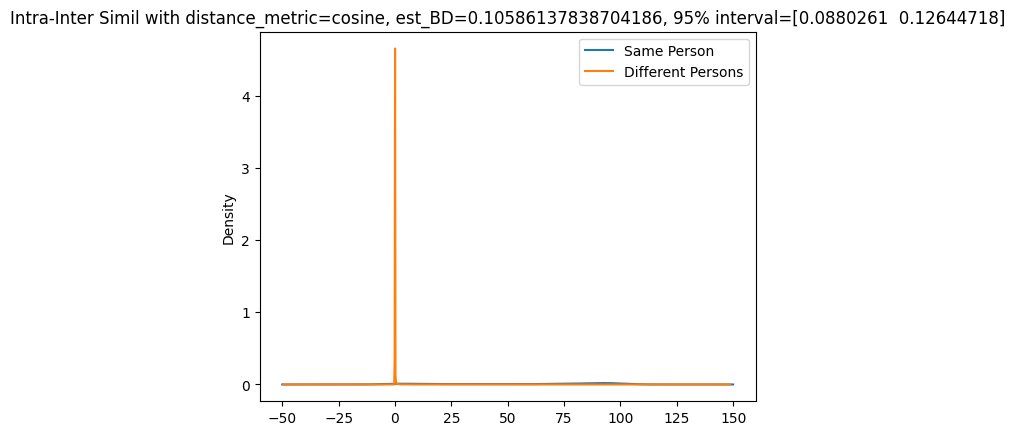

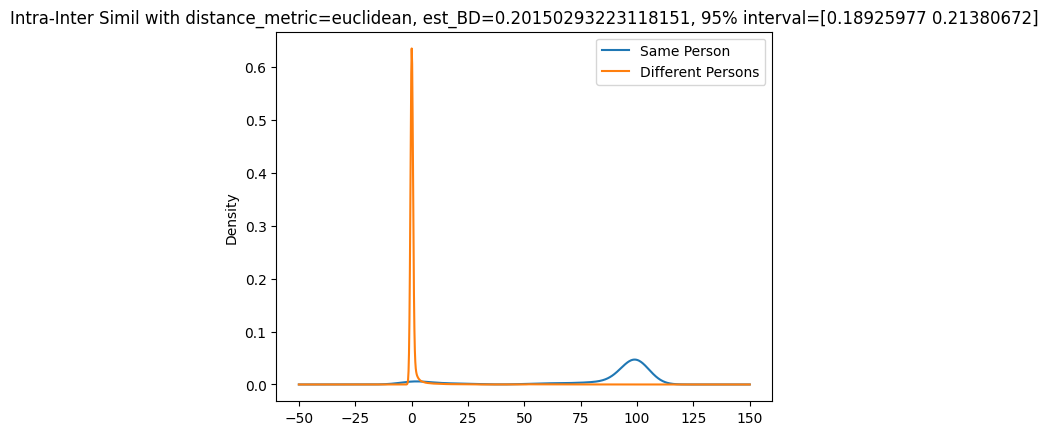

In [ ]:
for subset in ['1', '2', '3']:
  identities = i_subsets[subset]
  for model_idx in range(len(model_names)):
    for detector_backend in detectors:
      model_name = model_names[model_idx]
      print(f"\n-------\nRunning an experiment for {model_name} & {detector_backend}...\n-------\n")

      # build models in advance
      model = DeepFace.build_model(model_name)
      detector = DeepFace.build_model(task="face_detector", model_name=detector_backend)

      positives = []
      for key, values in identities.items():
        for i in range(0, len(values)-1):
          for j in range(i+1, len(values)):
            positive = []
            positive.append(values[i])
            positive.append(values[j])
            positives.append(positive)

      positives = pd.DataFrame(positives, columns = ["file_x", "file_y"])
      positives["actual"] = "Same Person"

      #############

      samples_list = list(identities.values())

      negatives = []
      for i in range(0, len(identities) - 1):
        for j in range(i+1, len(identities)):
          cross_product = itertools.product(samples_list[i], samples_list[j])
          cross_product = list(cross_product)

          for cross_sample in cross_product:
            negative = []
            negative.append(cross_sample[0])
            negative.append(cross_sample[1])
            negatives.append(negative)

      negatives = pd.DataFrame(negatives, columns = ["file_x", "file_y"])
      negatives["actual"] = "Different Persons"

      #############

      df = pd.concat([positives, negatives]).reset_index(drop = True)

      df.file_x = "intra-sim/"+df.file_x
      df.file_y = "intra-sim/"+df.file_y

      pivot = {}

      img1_embeddings = []
      img2_embeddings = []
      for index, instance in tqdm(df.iterrows(), total=df.shape[0]):
        try:
          img1_embeddings = img1_embeddings + represent(instance["file_x"])
          img2_embeddings = img2_embeddings + represent(instance["file_y"])
        except ValueError as e:
          img1_embeddings = []
          img2_embeddings = []
          print(e)

      df["img1_embeddings"] = img1_embeddings
      df["img2_embeddings"] = img2_embeddings

      for distance_metric in distance_metrics:
          distances = []
          for index, instance in tqdm(df.iterrows(), total=df.shape[0]):
              img1_embeddings = instance["img1_embeddings"]
              img2_embeddings = instance["img2_embeddings"]

              distance = find_distance(
                  alpha_embedding=img1_embeddings,
                  beta_embedding=img2_embeddings,
                  distance_metric=distance_metric
              )
              distances.append(distance)

          df[distance_metric] = distances

      for distance_metric in distance_metrics:
          threshold = find_threshold(model_name=model_name, distance_metric=distance_metric)
          df[f"{distance_metric}_threshold"] = threshold
          df[f"{distance_metric}_decision"] = 0
          idx = df[df[distance_metric] <= threshold].index
          df.loc[idx, f"{distance_metric}_decision"] = 1

      confidence_metrics = {}

      for distance_metric in distance_metrics:
          max_value = df[distance_metric].max()

          X = df[distance_metric].values.reshape(-1, 1)

          # normalize the distance values before feeding them to the model
          if max_value > 1:
              X = X / max_value

          y = df[f"{distance_metric}_decision"].values

          model = LogisticRegression().fit(X, y)

          w = model.coef_[0][0]
          b = model.intercept_[0]

          confidence_metrics[distance_metric] = {
              "w": w,
              "b": b,
              "normalizer": max_value,
          }

          confidences =[]
          for index, instance in df.iterrows():
              distance = instance[distance_metric]

              if max_value > 1:
                  distance = distance / max_value

              z = w * distance + b
              confidence = 100 / (1 + math.exp(-z))

              confidences.append(confidence)

          df[distance_metric + "_confidence"] = confidences

          confidence_metrics[distance_metric]["denorm_max_true"] = df[df[f"{distance_metric}_decision"] == 1][distance_metric + "_confidence"].max()
          confidence_metrics[distance_metric]["denorm_min_true"] = df[df[f"{distance_metric}_decision"] == 1][distance_metric + "_confidence"].min()

          confidence_metrics[distance_metric]["denorm_max_false"] = df[df[f"{distance_metric}_decision"] == 0][distance_metric + "_confidence"].max()
          confidence_metrics[distance_metric]["denorm_min_false"] = df[df[f"{distance_metric}_decision"] == 0][distance_metric + "_confidence"].min()

      # denormalize confidence scores
      for distance_metric in distance_metrics:
          for index, instance in df.iterrows():
              current_distance = instance[distance_metric]
              threshold = find_threshold(model_name=model_name, distance_metric=distance_metric)

              prediction = "same person" if current_distance <= threshold else "different persons"

              # denormalize same person predictions
              if prediction == "same person":
                  min_orginal = confidence_metrics[distance_metric]["denorm_min_true"]
                  max_orginal = confidence_metrics[distance_metric]["denorm_max_true"]
                  min_target = max(51, min_orginal)
                  max_target = 100
              else:
                  min_orginal = confidence_metrics[distance_metric]["denorm_min_false"]
                  max_orginal = confidence_metrics[distance_metric]["denorm_max_false"]
                  min_target = 0
                  max_target = min(49, max_orginal)

              confidence = instance[f"{distance_metric}_confidence"]

              confidence_new = (
                  (confidence - min_orginal) / (max_orginal - min_orginal)
              ) * (max_target - min_target) + min_target

              confidence_new = float(confidence_new)

              # print(f"{prediction}: {confidence}  -> {confidence_new}")

              df.loc[index, f"{distance_metric}_confidence"] = confidence_new

          df[df.actual == "Same Person"][f"{distance_metric}_confidence"].plot.kde(label="Same Person")
          df[df.actual == "Different Persons"][f"{distance_metric}_confidence"].plot.kde(label="Different Persons")

          intra = stats.gaussian_kde(df[df.actual == "Same Person"][f"{distance_metric}_confidence"])
          inter = stats.gaussian_kde(df[df.actual == "Different Persons"][f"{distance_metric}_confidence"])

          bd_s, bd = BD_mc(inter, intra, n=3000)

          plt.title(f'Intra-Inter Simil with distance_metric={distance_metric}, est_BD={bd}, 95% interval={bootstrap_CI(bd_s)}')
          plt.legend()
          plt.savefig(f"subset-{subset}-{detector_backend}-{model_name}-{distance_metric}.png", bbox_inches='tight')
          plt.show()

In [ ]:
! rm -rf plots
! mkdir plots
! mv *.png plots
! zip -r plots.zip plots